# 13 · Neural networks and autoencoders for EEG

**ROBT613 · Brain–Computer Interfaces** | Teaching session + independent lab

## Goal
Train a small temporal CNN and a denoising autoencoder using training-only normalization; compare what their losses actually measure.

**Data:** EEGBCI subject 1, runs 4/8/12; optional PyTorch

Run cells from top to bottom in a fresh CPU runtime. No previous notebook state is required.

## How to study this notebook

This is both the classroom lesson and the independent-study workbook. Everything needed for the exercises—questions, hints, executable solutions, checks and explanations—is here. Work from top to bottom in a fresh runtime.

1. Read the question and calculate a small example on paper.
2. Write your prediction before running the next code cell.
3. Try the practice task in its workspace.
4. Continue to the worked solution and compare the reasoning, not just the number.
5. Change one parameter and explain what the result means.

**For a live class:** pause at each “Try it” heading. The solution follows in the same notebook, so no separate answer document is required. Saved figures support reading without execution; downloading real data and rerunning cells requires internet on the first run. Code comments explain each analysis statement, and longer loops are explained before execution.

**Prerequisites:** basic Python arrays, arithmetic and plotting. The symbol guide below defines the mathematical notation used here. These lessons stay at the sensor level; EEG source imaging is outside the course.

## The question for today

A convolutional network can learn features directly from EEG, but a small dataset makes it easy to learn recording-specific shortcuts. We build a deliberately compact model, inspect its training process and compare reconstruction with classification as two different objectives.

### By the end you should be able to

- Track batch, channel and time dimensions through a temporal network.
- Explain logits, cross-entropy and gradient-based learning.
- Use a validation run for model selection and preserve a final test run.
- Distinguish reconstruction quality from physiological denoising and decoding utility.

**How to work:** predict each result before running it, execute one cell at a time, and write a short interpretation. The first worked examples use controlled arrays; the later walkthrough and applied practice use the dataset stated above. Practice workspaces, hints and worked solutions are placed beside the relevant methods. Complete your attempt before continuing to the reference solution.

## Setup
The first cell installs the tested core versions in Colab. Downloads are cached in `mne_data/`; a new Colab runtime loses that cache. A failed download is an error, never silently replaced by synthetic data.

In [1]:
# Colab: install before importing numerical libraries. Restart if pip requests it.
import sys, subprocess, os
if 'google.colab' in sys.modules:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q',
                           'mne==1.13.2', 'moabb==1.7.2'])
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mne
from scipy import signal
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (balanced_accuracy_score, roc_auc_score,
                             ConfusionMatrixDisplay, classification_report)
from sklearn.model_selection import (GroupKFold, cross_validate, GridSearchCV)
SEED = 613
rng = np.random.default_rng(SEED)
DATA_ROOT = Path(os.environ.get('BCI_DATA', './mne_data')).resolve()
DATA_ROOT.mkdir(parents=True, exist_ok=True)
os.environ['MNE_DATA'] = str(DATA_ROOT)
mne.set_log_level('WARNING')
plt.rcParams.update({'figure.figsize': (9, 4), 'font.size': 11,
                     'axes.spines.top': False, 'axes.spines.right': False})
import importlib.metadata as metadata
print({p: metadata.version(p) for p in ['mne','moabb','numpy','scipy','scikit-learn']})
print('Dataset cache:', DATA_ROOT)

{'mne': '1.13.2', 'moabb': '1.7.2', 'numpy': '2.1.3', 'scipy': '1.15.3', 'scikit-learn': '1.6.1'}
Dataset cache: <dataset-cache>


## Visual route through the lesson

Follow the arrows before running the analysis. For each box, say what the input represents, what changes, and what must be preserved.

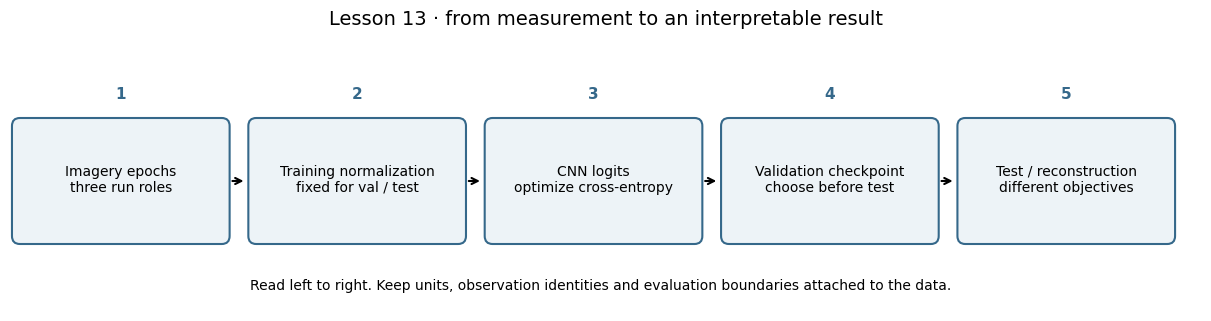

In [2]:
# Drawing code for the lesson map; no analysis data are transformed here.
from matplotlib.patches import FancyBboxPatch
map_steps=['Imagery epochs\nthree run roles', 'Training normalization\nfixed for val / test', 'CNN logits\noptimize cross-entropy', 'Validation checkpoint\nchoose before test', 'Test / reconstruction\ndifferent objectives']
fig,map_ax=plt.subplots(figsize=(12,3.1),constrained_layout=True)
map_ax.set(xlim=(-.1,12),ylim=(-.3,2.4));map_ax.axis('off')
for map_i,map_label in enumerate(map_steps):
    map_x=map_i*2.4
    map_ax.add_patch(FancyBboxPatch((map_x,.45),2.05,1.1,
        boxstyle='round,pad=0.08',facecolor='#edf3f7',edgecolor='#35688a',linewidth=1.5))
    map_ax.text(map_x+1.025,1.02,map_label,ha='center',va='center',fontsize=10)
    map_ax.text(map_x+1.025,1.83,str(map_i+1),ha='center',weight='bold',color='#35688a')
    if map_i<4:map_ax.annotate('',xy=(map_x+2.3,1),xytext=(map_x+2.13,1),arrowprops=dict(arrowstyle='->',lw=1.5))
map_ax.text(5.9,-.08,'Read left to right. Keep units, observation identities and evaluation boundaries attached to the data.',ha='center',fontsize=10)
map_ax.set_title('Lesson 13 · from measurement to an interpretable result',fontsize=14,pad=12)
plt.show()

**Read the map:** the arrows represent processing order, not permission to fit on all observations. When a stage learns parameters, keep evaluation data outside that fit. The map is also available as text: Imagery epochs: three run roles → Training normalization: fixed for val / test → CNN logits: optimize cross-entropy → Validation checkpoint: choose before test → Test / reconstruction: different objectives.

## Symbols and a calculation by hand

$z_k$: class logit; $p_k$: class probability; $y$: correct label; $\theta$: trainable weights; $\eta$: learning rate.

### Derive the operation before calling the library

Softmax is $p_k=e^{z_k}/\sum_je^{z_j}$. Subtracting the same maximum $m$ cancels between numerator and denominator, producing the stable expression $e^{z_k-m}/\sum_je^{z_j-m}$. Cross-entropy for a correct-class probability of 0.5 is $-\ln0.5=0.693$; a confident error with probability 0.01 costs about 4.605.

For a softmax classifier, the loss derivative with respect to logit $z_k$ is $p_k-\mathbf1[k=y]$. Gradient descent updates $\theta\leftarrow\theta-\eta\nabla_\theta\mathcal L$. `backward` calculates derivatives; `step` changes weights; `zero_grad` prevents unintended accumulation. A convolution has $C_{out}(C_{in}K+1)$ parameters when it includes a bias per output channel.

### Your paper calculation

Rewrite one equation with the numerical example above. Name the input units and output units, and identify the axis being reduced or transformed.

**My calculation:** _write your intermediate steps here before continuing._

### Learned features still need an experimental design

A neural network replaces some hand-designed feature operations with trainable transformations. It does not replace channel inspection, correct event labels or independent evaluation. With a small number of EEG trials, the model can memorize quirks of one recording. The compact architecture here is a teaching baseline, not a claim that deep learning outperforms CSP.

PyTorch `Conv1d` expects batch × channel × time. A temporal kernel has a finite support and slides across the time axis. With stride one and suitable padding, the output retains the time length while changing the number of feature channels. Nonlinear activation allows later layers to express more than one linear transformation. Pooling summarizes time; a final linear layer maps the representation to class logits.

For $C_{in}$ input channels, $C_{out}$ output channels and kernel size $K$, a convolution with one bias per output channel contains

$$C_{out}(C_{in}K+1)$$

parameters. Counting parameters helps make capacity concrete. It does not by itself determine how much data a model needs, because regularization, task structure and signal quality also matter.

### Scores, probabilities and the loss

The network outputs logits $z_k$, unrestricted real-valued scores. Softmax converts them to probabilities,

$$p_k=\frac{e^{z_k}}{\sum_j e^{z_j}},\qquad \mathcal L=-\frac1N\sum_n\log p_{n,y_n}.$$

For numerical stability, a common constant can be subtracted from the logits before exponentiation. PyTorch cross-entropy takes logits directly and handles the stable calculation internally; do not apply softmax before passing outputs to that loss.

Backpropagation computes derivatives of the loss with respect to weights. An optimizer updates the weights to reduce training loss. Learning rate controls step size; too large can make optimization unstable, while too small can make progress slow. Training loss alone cannot tell us whether the representation transfers to new recordings.

### Three separate roles for three runs

The training run fits normalization and network weights. The validation run selects a checkpoint and supports limited development. The final test run is used once for evaluation of the selected model. Normalization uses only training statistics and preserves the same channel order for all partitions. If validation performance is repeatedly inspected while redesigning the model, that run has become part of development; the untouched test run remains necessary.

A random seed improves repeatability but does not turn one run split into population evidence. CPU/GPU kernels and library changes can also affect numerical reproducibility. Report the architecture, seed, optimizer, epoch budget and split, and compare a simple baseline under the same protocol before arguing for a more complex method.

### Autoencoding is a different learning problem

An autoencoder maps input to a compact representation and reconstructs it. Mean squared error is $\|\hat X-X\|^2/N_{elements}$. A denoising exercise adds known synthetic corruption and predicts the original measured EEG. That target is not perfectly clean brain activity: it already contains biological and recording artifacts. Improved reconstruction against this target establishes resistance to the injected noise, not removal of every real artifact or preservation of every task signal.

## Visual intuition · See the loss push probabilities toward the correct class

**Try it:** Compare correct-class probabilities 0.5 and 0.01. Which prediction receives the larger penalty?

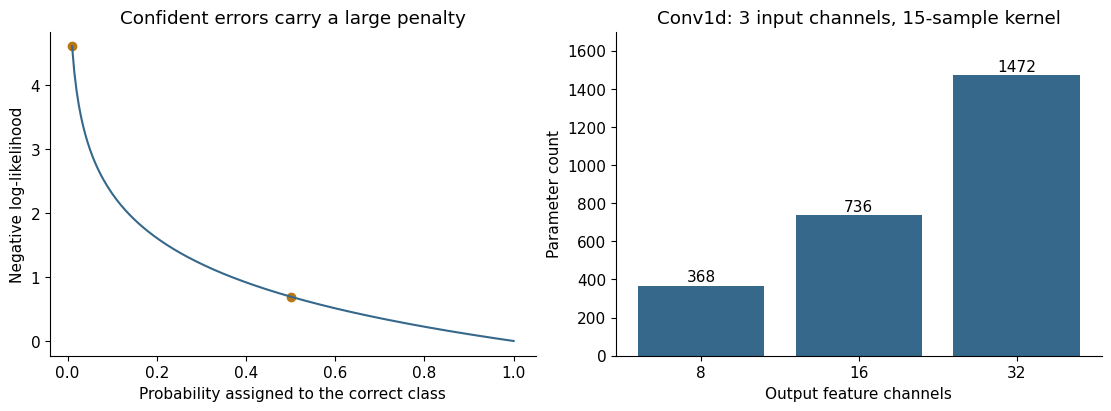

In [3]:
vis_p=np.linspace(.01,1,200)
fig,axes=plt.subplots(1,2,figsize=(11,4),constrained_layout=True)
axes[0].plot(vis_p,-np.log(vis_p),color='#35688a')
axes[0].scatter([.01,.5],-np.log([.01,.5]),color='#b87714')
axes[0].set(xlabel='Probability assigned to the correct class',ylabel='Negative log-likelihood',title='Confident errors carry a large penalty')
vis_width=np.array([8,16,32]);vis_params=vis_width*(3*15+1)
axes[1].bar(vis_width.astype(str),vis_params,color='#35688a')
for i,v in enumerate(vis_params):axes[1].text(i,v+20,str(v),ha='center')
axes[1].set(ylim=(0,1700),xlabel='Output feature channels',ylabel='Parameter count',title='Conv1d: 3 input channels, 15-sample kernel')
plt.show()

### Worked interpretation

Cross-entropy responds to confidence as well as correctness. The parameter chart is an illustrative layer, not the full network below, whose actual input channel count is read from X. More parameters increase capacity without increasing the number of calibration trials.

## Guided practice 1 · stable softmax

Turn logits into probabilities after subtracting their maximum. Show that a shared offset has no effect.

**Try it on paper:** predict the output’s shape, sign or approximate value. State which assumption makes your prediction valid.

**My prediction:** _write here._

**Hint:** trace one sample, one channel or one trial through the calculation before considering the full array.

### Worked solution · read one statement at a time

In [4]:
demo_logits=np.array([2.,1.,-1.])
def demo_softmax(z):
    ex=np.exp(z-z.max());return ex/ex.sum()
print('Probabilities:',demo_softmax(demo_logits))
assert np.allclose(demo_softmax(demo_logits),demo_softmax(demo_logits+1000))

Probabilities: [0.70538451 0.25949646 0.03511903]


### Why this result makes sense

Only relative logits matter. Subtracting the maximum avoids unnecessary overflow without changing the result.

**Check your understanding:** change one numerical parameter, predict the direction of change, and rerun. If the result disagrees, inspect units and axes before changing the method.

## Guided practice 2 · count convolution parameters

Compare two layer widths while keeping channels and kernel length fixed.

**Try it on paper:** predict the output’s shape, sign or approximate value. State which assumption makes your prediction valid.

**My prediction:** _write here._

**Hint:** trace one sample, one channel or one trial through the calculation before considering the full array.

### Worked solution · read one statement at a time

In [5]:
for output_channels in [8,16,32]:
    print(output_channels,'feature channels:',output_channels*(3*15+1),'parameters')

8 feature channels: 368 parameters
16 feature channels: 736 parameters
32 feature channels: 1472 parameters


### Why this result makes sense

Increasing width adds trainable capacity even when the input trial count stays fixed.

**Check your understanding:** change one numerical parameter, predict the direction of change, and rerun. If the result disagrees, inspect units and axes before changing the method.

## Guided practice 3 · cross-entropy penalizes confident errors

Evaluate the loss for several probabilities assigned to the correct class.

**Try it on paper:** predict the output’s shape, sign or approximate value. State which assumption makes your prediction valid.

**My prediction:** _write here._

**Hint:** trace one sample, one channel or one trial through the calculation before considering the full array.

### Worked solution · read one statement at a time

In [6]:
demo_correct_probability=np.array([.99,.8,.5,.1,.01])
print(pd.DataFrame({'Correct-class probability':demo_correct_probability,'Loss':-np.log(demo_correct_probability)}))

   Correct-class probability      Loss
0                       0.99  0.010050
1                       0.80  0.223144
2                       0.50  0.693147
3                       0.10  2.302585
4                       0.01  4.605170


### Why this result makes sense

Two models with the same hard-label accuracy can have very different cross-entropy because their confidence differs.

**Check your understanding:** change one numerical parameter, predict the direction of change, and rerun. If the result disagrees, inspect units and axes before changing the method.

## Guided practice 4 · reconstruction targets matter

Compare a zero predictor with a predictor that preserves a small event but misses a large background.

**Try it on paper:** predict the output’s shape, sign or approximate value. State which assumption makes your prediction valid.

**My prediction:** _write here._

**Hint:** trace one sample, one channel or one trial through the calculation before considering the full array.

### Worked solution · read one statement at a time

In [7]:
demo_target=np.array([10.,10.,1.,0.])
demo_preserve_background=np.array([10.,10.,0.,0.])
demo_preserve_event=np.array([0.,0.,1.,0.])
print('MSE, background preserved:',np.mean((demo_target-demo_preserve_background)**2))
print('MSE, event preserved:',np.mean((demo_target-demo_preserve_event)**2))

MSE, background preserved: 0.25
MSE, event preserved: 50.0


### Why this result makes sense

MSE is dominated by large-amplitude terms. A low reconstruction loss need not preserve the small feature needed for a BCI decision.

**Check your understanding:** change one numerical parameter, predict the direction of change, and rerun. If the result disagrees, inspect units and axes before changing the method.

## Practice 1 · Cross-entropy function

Implement mean_nll for a vector of probabilities assigned to the correct class. Use values strictly between zero and one.

**Try it:** complete the function below before reading its solution. The template deliberately returns None so that an unfinished attempt does not interrupt the rest of the lesson.

In [8]:
def mean_nll(correct_class_probabilities):
    # TODO: average negative natural-log probability.
    return None

### Hint

Use the equation above and keep the trial/channel axes intact unless the requested output removes them. Test the smallest example by hand first.

### Worked solution

Compare this implementation with your attempt. The next cell checks the reference answer on a concrete numerical case.

In [9]:
def mean_nll(correct_class_probabilities):
    return -np.log(correct_class_probabilities).mean()

In [10]:
answer=mean_nll(np.array([.5,.5]))
if answer is not None:
    assert np.isclose(answer,np.log(2)); print('Loss check passed.')
else: print('Exercise pending: implement mean_nll.')

Loss check passed.


## Apply the ideas to the complete pipeline

The next stages use the real recording or the explicitly labeled simulation described in the lesson. Keep preprocessing, feature extraction and evaluation decisions visible. Read each stage’s explanation before running its code.

### Method reference for the pipeline

A temporal convolution computes $h_{k,t}=\phi(b_k+\sum_{c,\tau}W_{kc\tau}X_{c,t-\tau})$. Weight sharing reduces parameter count relative to a fully connected network. Cross-entropy $L=-N^{-1}\sum_i\log p_\theta(y_i|X_i)$ rewards correct class probabilities. Dropout and weight decay regularize but do not replace independent evaluation.

An autoencoder maps $z=f_\theta(X)$ and $\hat X=g_\phi(z)$, minimizing $\|X-\hat X\|^2$. A denoising autoencoder receives deliberately corrupted $\tilde X$ while targeting $X$. Real EEG used as a target is not artifact-free ground truth; low reconstruction error can preserve artifacts or suppress discriminative transients. A bottleneck is a modeling assumption, not evidence of neural source recovery.

Use one run for training, one for validation and one for testing. Fit channel scaling on training samples only. Select the best epoch from validation loss and evaluate the test run once. This small-data exercise is not intended to establish deep-learning superiority over CSP/LDA.

## Load EEG and PyTorch
CPU execution is sufficient. PyTorch is optional for the rest of the course.

The three runs have separate training, validation and test roles. Training-only normalization is applied consistently to all partitions; tensors retain the batch × channel × time organization required by Conv1d.

### Step 1.1 · trace the next operation

**1.** Import the named tools used in this step.

**2.** Make the analysis choice visible and fixed before inspecting evaluation performance.

**3.** Store this intermediate result so the next operation can be traced and inspected.

In [11]:
# Import the named tools used in this step.
from mne.datasets import eegbci
# Make the analysis choice visible and fixed before inspecting evaluation performance.
runs = [4, 8, 12]
# Store this intermediate result so the next operation can be traced and inspected.
parts, groups = ([], [])

### Step 1.2 · trace the next operation

**1.** Process each run independently; carry its run ID into every resulting trial.

In [12]:
# Process each run independently; carry its run ID into every resulting trial.
for run in runs:
    # Retrieve this run independently so filtering does not cross a run boundary.
    paths = eegbci.load_data(1, [run], path=DATA_ROOT, update_path=False)
    # Load this run’s continuous recording and its sampling metadata.
    raw_run = mne.io.read_raw_edf(paths[0], preload=True, verbose=False)
    # Make sensor names consistent with the montage and later channel selections.
    eegbci.standardize(raw_run)
    # Attach sensor locations; no anatomical inverse model is used.
    raw_run.set_montage('standard_1005')
    # Use the same reference convention for every run.
    raw_run.set_eeg_reference('average', projection=False)
    # Filter the continuous run before extracting its trials.
    raw_run.filter(8, 30, fir_design='firwin')
    # Map only the documented imagery cues to the two class codes.
    events, _ = mne.events_from_annotations(raw_run, event_id={'T1': 1, 'T2': 2})
    # Extract the stated post-cue interval while retaining condition labels.
    ep = mne.Epochs(raw_run, events, {'left': 1, 'right': 2}, tmin=0.5, tmax=3.5, baseline=None, preload=True, picks='eeg', reject_by_annotation=True)
    # Retain this run’s epoch object for the later concatenation.
    parts.append(ep)
    # Append exactly one run identifier for every retained trial.
    groups.extend([run] * len(ep))

/tmp/ipykernel_467213/3715406244.py:6: FutureWarning: Montage name 'standard_1005' is deprecated and will be removed in MNE 1.14. Use 'colin27_1005' instead.
  raw_run.set_montage('standard_1005')


/tmp/ipykernel_467213/3715406244.py:6: FutureWarning: Montage name 'standard_1005' is deprecated and will be removed in MNE 1.14. Use 'colin27_1005' instead.
  raw_run.set_montage('standard_1005')
/tmp/ipykernel_467213/3715406244.py:6: FutureWarning: Montage name 'standard_1005' is deprecated and will be removed in MNE 1.14. Use 'colin27_1005' instead.
  raw_run.set_montage('standard_1005')


### Step 1.3 · trace the next operation

**1.** Join trial collections while retaining one aligned group label per trial.

**2.** Expose the numerical array; EEG values are in volts and the final axis is time.

**3.** Keep one label or grouping identifier per trial in exactly the same order as the EEG array.

**4.** Make an explicit NumPy vector while preserving its current row order.

**5.** Display a bounded diagnostic; read the units, shape or partition rather than treating output as a success label.

**6.** Import the named tools used in this step.

In [13]:
# Join trial collections while retaining one aligned group label per trial.
epochs = mne.concatenate_epochs(parts)
# Expose the numerical array; EEG values are in volts and the final axis is time.
X = epochs.get_data(copy=True)
# Keep one label or grouping identifier per trial in exactly the same order as the EEG array.
y = epochs.events[:, 2] - 1
# Make an explicit NumPy vector while preserving its current row order.
groups = np.asarray(groups)
# Display a bounded diagnostic; read the units, shape or partition rather than treating output as a success label.
print('Epochs:', X.shape, 'run counts:', pd.Series(groups).value_counts().to_dict())
# Import the named tools used in this step.
import importlib.util

Epochs: (45, 64, 481) run counts: {4: 15, 8: 15, 12: 15}


/tmp/ipykernel_467213/2755599804.py:2: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  epochs = mne.concatenate_epochs(parts)


### Step 1.4 · trace the next operation

**1.** Apply the stated operation to the current object; use the surrounding explanation to check its role.

**2.** Import the named tools used in this step.

**3.** Import the named tools used in this step.

**4.** Make random initialization reproducible for this demonstration.

**5.** Apply the stated operation to the current object; use the surrounding explanation to check its role.

**6.** Create an explicit partition mask; use the same mask for data, labels and metadata.

In [14]:
# Apply the stated operation to the current object; use the surrounding explanation to check its role.
if importlib.util.find_spec('torch') is None:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'torch'])
# Import the named tools used in this step.
import torch
# Import the named tools used in this step.
from torch import nn
# Make random initialization reproducible for this demonstration.
torch.manual_seed(SEED)
# Apply the stated operation to the current object; use the surrounding explanation to check its role.
torch.set_num_threads(2)
# Create an explicit partition mask; use the same mask for data, labels and metadata.
tr = groups == 4

### Step 1.5 · trace the next operation

**1.** Create an explicit partition mask; use the same mask for data, labels and metadata.

**2.** Create an explicit partition mask; use the same mask for data, labels and metadata.

**3.** Estimate channel normalization from training trials only; reuse it unchanged elsewhere.

**4.** Estimate channel normalization from training trials only; reuse it unchanged elsewhere.

**5.** Convert numerical arrays to tensors with an explicit data type.

**6.** Convert numerical arrays to tensors with an explicit data type.

**7.** Convert numerical arrays to tensors with an explicit data type.

In [15]:
# Create an explicit partition mask; use the same mask for data, labels and metadata.
va = groups == 8
# Create an explicit partition mask; use the same mask for data, labels and metadata.
te = groups == 12
# Estimate channel normalization from training trials only; reuse it unchanged elsewhere.
mu = X[tr].mean(axis=(0, 2), keepdims=True)
# Estimate channel normalization from training trials only; reuse it unchanged elsewhere.
sd = X[tr].std(axis=(0, 2), keepdims=True).clip(1e-12)
# Convert numerical arrays to tensors with an explicit data type.
Z = torch.tensor((X - mu) / sd, dtype=torch.float32)
# Convert numerical arrays to tensors with an explicit data type.
Y = torch.tensor(y, dtype=torch.long)
# Convert numerical arrays to tensors with an explicit data type.
tr_t = torch.tensor(tr)

### Step 1.6 · trace the next operation

**1.** Convert numerical arrays to tensors with an explicit data type.

**2.** Convert numerical arrays to tensors with an explicit data type.

**3.** Display a bounded diagnostic; read the units, shape or partition rather than treating output as a success label.

In [16]:
# Convert numerical arrays to tensors with an explicit data type.
va_t = torch.tensor(va)
# Convert numerical arrays to tensors with an explicit data type.
te_t = torch.tensor(te)
# Display a bounded diagnostic; read the units, shape or partition rather than treating output as a success label.
print('Train/validation/test:', tr.sum(), va.sum(), te.sum())

Train/validation/test: 15 15 15


### Inspect and interpret

Check sample counts per partition and the normalization shape. Verify that the final test tensor is not used to choose network weights or checkpoint.

**Record in your notes:** the relevant shape/count or metric, the units where applicable, and one limitation of the inference.

## Practice 2 · Inspect normalization without refitting it

**Try it:** Check training-channel means and standard deviations after normalization. Compare the validation means.

**My reasoning / hand calculation:** _write here._

In [17]:
# Your attempt goes here. Work on copies and preserve the evaluation split.

### Hint

Z was formed from training-only mu and sd; validation is allowed to remain shifted.

### Worked solution

Run the following calculation after attempting your own version.

In [18]:
print('Training normalized channel means (first five):',Z[tr_t].mean(dim=(0,2))[:5])
print('Validation channel means (first five):',Z[va_t].mean(dim=(0,2))[:5])
print('Train / validation / test counts:',tr.sum(),va.sum(),te.sum())

Training normalized channel means (first five): tensor([ 8.2612e-10, -9.9135e-11, -9.9135e-10,  3.3045e-10, -1.3879e-09])
Validation channel means (first five): tensor([ 0.0005, -0.0006, -0.0002, -0.0010, -0.0015])
Train / validation / test counts: 15 15 15


### Interpret and check

Training means should be near zero up to floating-point precision. Validation means need not be zero; using them to recenter would change the evaluation procedure. All partitions must retain the same channel order.

## Train a small CNN
Global average pooling yields a fixed-sized feature vector. Validation selects a checkpoint, never a test result.

A compact temporal convolution and global pooling produce class logits. Training updates parameters, validation selects the saved checkpoint, and the test run evaluates that selected checkpoint.

### Step 2.1 · trace the next operation

**1.** Import the named tools used in this step.

**2.** Define the network’s ordered transformations; inspect dimensions at each layer.

**3.** Configure gradient-based parameter updates with the declared learning rate.

**4.** Use logits directly; this loss includes the stable softmax calculation.

**5.** Initialize the collection that will retain outputs in the same order as the inputs.

**6.** Store this intermediate result so the next operation can be traced and inspected.

**7.** Store this intermediate result so the next operation can be traced and inspected.

In [19]:
# Import the named tools used in this step.
import copy
# Define the network’s ordered transformations; inspect dimensions at each layer.
net = nn.Sequential(nn.Conv1d(X.shape[1], 16, 15, padding=7), nn.ELU(), nn.AvgPool1d(4), nn.Dropout(0.25), nn.Conv1d(16, 16, 9, padding=4), nn.ELU(), nn.AdaptiveAvgPool1d(1), nn.Flatten(), nn.Linear(16, 2))
# Configure gradient-based parameter updates with the declared learning rate.
opt = torch.optim.Adam(net.parameters(), lr=0.001, weight_decay=0.01)
# Use logits directly; this loss includes the stable softmax calculation.
loss_fn = nn.CrossEntropyLoss()
# Initialize the collection that will retain outputs in the same order as the inputs.
history = []
# Store this intermediate result so the next operation can be traced and inspected.
best_loss = float('inf')
# Store this intermediate result so the next operation can be traced and inspected.
best = None

### Step 2.2 · trace the next operation

**1.** Repeat training updates; evaluate on validation data after each update and retain the best checkpoint.

In [20]:
# Repeat training updates; evaluate on validation data after each update and retain the best checkpoint.
for epoch in range(30):
    # Enable training behavior, including dropout, for the parameter update.
    net.train()
    # Clear accumulated gradients before differentiating this training loss.
    opt.zero_grad()
    # Calculate cross-entropy from training logits and their true labels.
    loss = loss_fn(net(Z[tr_t]), Y[tr_t])
    # Differentiate the training loss with respect to each trainable parameter.
    loss.backward()
    # Update model parameters using the stored gradients.
    opt.step()
    # Disable dropout for validation or final evaluation.
    net.eval()
    # Do not build a gradient graph: these calculations must not train the model.
    with torch.no_grad():
        # Measure validation loss solely to choose the checkpoint.
        val = loss_fn(net(Z[va_t]), Y[va_t]).item()
    # Store training/validation losses to inspect learning behavior later.
    history.append((loss.item(), val))
    # Replace the checkpoint only when validation loss improves.
    if val < best_loss:
        # Remember the best validation value seen so far.
        best_loss = val
        # Copy parameter values now; a reference would keep changing with later training.
        best = copy.deepcopy(net.state_dict())

### Step 2.3 · trace the next operation

**1.** Restore the checkpoint chosen by validation rather than automatically using the last epoch.

**2.** Disable training-specific dropout behavior before evaluation.

In [21]:
# Restore the checkpoint chosen by validation rather than automatically using the last epoch.
net.load_state_dict(best)
# Disable training-specific dropout behavior before evaluation.
net.eval()

Sequential(
  (0): Conv1d(64, 16, kernel_size=(15,), stride=(1,), padding=(7,))
  (1): ELU(alpha=1.0)
  (2): AvgPool1d(kernel_size=(4,), stride=(4,), padding=(0,))
  (3): Dropout(p=0.25, inplace=False)
  (4): Conv1d(16, 16, kernel_size=(9,), stride=(1,), padding=(4,))
  (5): ELU(alpha=1.0)
  (6): AdaptiveAvgPool1d(output_size=1)
  (7): Flatten(start_dim=1, end_dim=-1)
  (8): Linear(in_features=16, out_features=2, bias=True)
)

### Step 2.4 · trace the next operation

**1.** Evaluate without building a gradient graph; these observations do not update model weights.

In [22]:
# Evaluate without building a gradient graph; these observations do not update model weights.
with torch.no_grad():
    pred = net(Z[te_t]).argmax(1).numpy()

### Step 2.5 · trace the next operation

**1.** Average class recalls so majority-class frequency does not dominate the score.

In [23]:
# Average class recalls so majority-class frequency does not dominate the score.
print('Test-run balanced accuracy:', balanced_accuracy_score(y[te], pred))

Test-run balanced accuracy: 0.7321428571428572


### Step 2.6 · trace the next operation

**1.** Create axes; plotting changes the display, not the analyzed data.

**2.** Apply the stated operation to the current object; use the surrounding explanation to check its role.

**3.** Apply the stated operation to the current object; use the surrounding explanation to check its role.

**4.** Apply the stated operation to the current object; use the surrounding explanation to check its role.

**5.** Render the completed figure and inspect labels, units and the comparison.

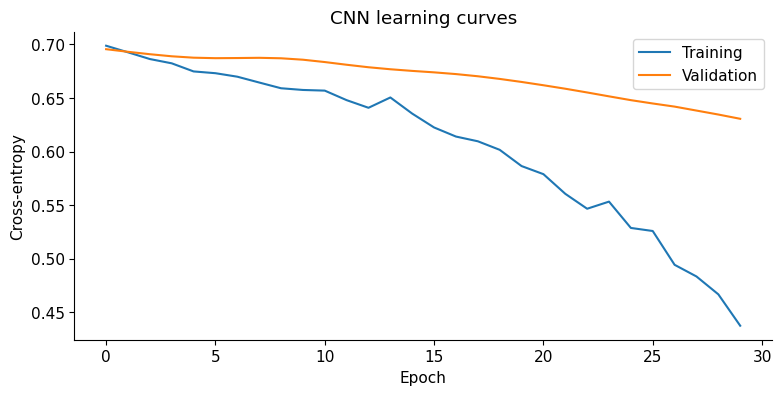

In [24]:
# Create axes; plotting changes the display, not the analyzed data.
fig, ax = plt.subplots()
# Apply the stated operation to the current object; use the surrounding explanation to check its role.
ax.plot(history)
# Apply the stated operation to the current object; use the surrounding explanation to check its role.
ax.set(xlabel='Epoch', ylabel='Cross-entropy', title='CNN learning curves')
# Apply the stated operation to the current object; use the surrounding explanation to check its role.
ax.legend(['Training', 'Validation'])
# Render the completed figure and inspect labels, units and the comparison.
plt.show()

### Inspect and interpret

Read learning curves before the final metric. If training improves while validation worsens, explain why the last epoch is not automatically the best model.

**Record in your notes:** the relevant shape/count or metric, the units where applicable, and one limitation of the inference.

## Practice 3 · Trace shapes through the actual network

**Try it:** Pass a two-trial batch through each layer and print the output shape. Count the actual trainable parameters.

**My reasoning / hand calculation:** _write here._

In [25]:
# Your attempt goes here. Work on copies and preserve the evaluation split.

### Hint

Set evaluation mode so dropout does not randomly zero activations during the inspection.

### Worked solution

Run the following calculation after attempting your own version.

In [26]:
net.eval()
lab_tensor=Z[tr_t][:2]
print('Input:',tuple(lab_tensor.shape))
with torch.no_grad():
    for lab_layer in net:
        lab_tensor=lab_layer(lab_tensor)
        print(type(lab_layer).__name__,tuple(lab_tensor.shape))
print('Trainable parameters:',sum(p.numel() for p in net.parameters() if p.requires_grad))

Input: (2, 64, 481)
Conv1d (2, 16, 481)
ELU (2, 16, 481)
AvgPool1d (2, 16, 120)
Dropout (2, 16, 120)
Conv1d (2, 16, 120)
ELU (2, 16, 120)
AdaptiveAvgPool1d (2, 16, 1)
Flatten (2, 16)
Linear (2, 2)
Trainable parameters: 17730


### Interpret and check

Conv1d changes feature channels while its padding preserves temporal length here; pooling reduces time resolution; adaptive pooling collapses time to one value per feature channel; the final linear layer returns two logits per trial. Logits go directly into CrossEntropyLoss.

## Practice 4 · Explain each training-loop operation

**Try it:** What do zero_grad, backward and step do, and why is validation computed without gradients?

**My reasoning / hand calculation:** _write here._

**My answer:** _write a short explanation before continuing._

### Hint

Separate storing derivatives from changing weights.

### Worked solution

zero_grad clears previously accumulated parameter gradients. backward differentiates the current training loss and stores gradients. step updates weights using those gradients. no_grad prevents graph construction for validation, and eval disables training-specific dropout behavior. The validation score chooses a checkpoint; it does not directly update weights.

## Train a denoising autoencoder
Only training epochs are used. The target is recorded EEG, not verified clean EEG. Evaluate added-noise reconstruction on the validation set, leaving the test set for the classifier result above.

The autoencoder is trained against recorded EEG after adding controlled noise. Its reconstruction objective differs from the classifier’s label objective. Validation compares the reconstructed signal to the recorded target under the stated corruption.

### Step 3.1 · trace the next operation

**1.** Define the network’s ordered transformations; inspect dimensions at each layer.

**2.** Configure gradient-based parameter updates with the declared learning rate.

In [27]:
# Define the network’s ordered transformations; inspect dimensions at each layer.
ae = nn.Sequential(nn.Conv1d(X.shape[1], 8, 9, padding=4), nn.ELU(), nn.Conv1d(8, X.shape[1], 9, padding=4))
# Configure gradient-based parameter updates with the declared learning rate.
optimizer = torch.optim.Adam(ae.parameters(), lr=0.003)

### Step 3.2 · trace the next operation

**1.** Add known synthetic corruption, reconstruct the recorded training target and update autoencoder weights.

In [28]:
# Add known synthetic corruption, reconstruct the recorded training target and update autoencoder weights.
for _ in range(20):
    # Add known synthetic noise; the target is still recorded EEG, not perfectly clean brain activity.
    corrupted = Z[tr_t] + 0.2 * torch.randn_like(Z[tr_t])
    # Clear accumulated gradients before differentiating this training loss.
    optimizer.zero_grad()
    # Measure reconstruction error against the recorded training target.
    loss = ((ae(corrupted) - Z[tr_t]) ** 2).mean()
    # Differentiate the training loss with respect to each trainable parameter.
    loss.backward()
    # Update model parameters using the stored gradients.
    optimizer.step()

### Step 3.3 · trace the next operation

**1.** Apply the stated operation to the current object; use the surrounding explanation to check its role.

In [29]:
# Apply the stated operation to the current object; use the surrounding explanation to check its role.
ae.eval()

Sequential(
  (0): Conv1d(64, 8, kernel_size=(9,), stride=(1,), padding=(4,))
  (1): ELU(alpha=1.0)
  (2): Conv1d(8, 64, kernel_size=(9,), stride=(1,), padding=(4,))
)

### Step 3.4 · trace the next operation

**1.** Evaluate without building a gradient graph; these observations do not update model weights.

In [30]:
# Evaluate without building a gradient graph; these observations do not update model weights.
with torch.no_grad():
    # Create held-out synthetic corruption for a reconstruction check.
    noisy = Z[va_t] + 0.2 * torch.randn_like(Z[va_t])
    # Apply the fitted autoencoder without changing its weights.
    reconstructed = ae(noisy)
    print('Validation MSE: noisy input', ((noisy - Z[va_t]) ** 2).mean().item(), 'autoencoder', ((reconstructed - Z[va_t]) ** 2).mean().item())

Validation MSE: noisy input 0.039917685091495514 autoencoder 0.3346235454082489


### Step 3.5 · trace the next operation

**1.** Display a bounded diagnostic; read the units, shape or partition rather than treating output as a success label.

In [31]:
# Display a bounded diagnostic; read the units, shape or partition rather than treating output as a success label.
print('A worse reconstruction score is a valid outcome; do not claim denoising succeeded automatically.')

A worse reconstruction score is a valid outcome; do not claim denoising succeeded automatically.


### Inspect and interpret

Report the unchanged noisy-input baseline as well as reconstructed MSE in the exercise. A low error against recorded EEG does not certify removal of real ocular or muscle artifacts.

**Record in your notes:** the relevant shape/count or metric, the units where applicable, and one limitation of the inference.

## Practice 5 · Judge the autoencoder against a baseline

**Try it:** If reconstructed MSE exceeds the unchanged noisy-input MSE, can the notebook claim successful denoising?

**My reasoning / hand calculation:** _write here._

**My answer:** _write a short explanation before continuing._

### Hint

The simpler identity baseline is already available.

### Worked solution

No. It failed to improve that stated reconstruction objective under the tested corruption. Even lower MSE would only show improvement against recorded EEG plus synthetic noise; recorded targets can already contain real artifacts. Preservation of task-relevant features needs separate evaluation.

## Practice 6 · explain the complete method

Without looking back, explain the measurement, transformation, feature or summary, and the evaluation boundary. Include one failure mode and one claim the result does not establish.

**My explanation:** _write here._

### Worked answer · compare your reasoning

The training loop learns parameters; validation chooses a checkpoint; the final test estimates transfer under that choice. Reconstruction and classification optimize different targets. A more complex model must be compared fairly with a simple baseline.

## If your result is different

If dimensions fail at Conv1d, check batch × channel × time ordering. If validation worsens while training improves, inspect overfitting and checkpoint selection before adding more layers.

If a dataset download fails, read the error and retry when the public host is reachable; do not silently replace real data with simulated values. If a notebook cell refers to an undefined variable, restart the kernel and run the preceding cells in order. Numerical scores can vary slightly with library versions; record versions and compare the protocol before concluding that a method changed.

## Can you now do this independently?

- Explain each arrow in the lesson map and the units at its boundaries.
- Reproduce the hand calculation and point to its corresponding code.
- Interpret the figures without turning a descriptive pattern into an unsupported causal claim.
- Complete a practice task before reading its worked solution.
- State which choices were fixed and which were learned from calibration data.

If one item is unclear, return to the associated figure or practice section before the next lesson.

## Next steps and sources
[PyTorch training basics](https://pytorch.org/tutorials/beginner/basics/optimization_tutorial.html) · [MNE EEGBCI](https://mne.tools/stable/generated/mne.datasets.eegbci.load_data.html).

Record package versions, subject/run IDs, preprocessing, split unit, random seed, and all exclusions with your results. Do not interpret a single participant as a population estimate.